機器手臂範例一-以等角度間隔取樣本-繪製角度

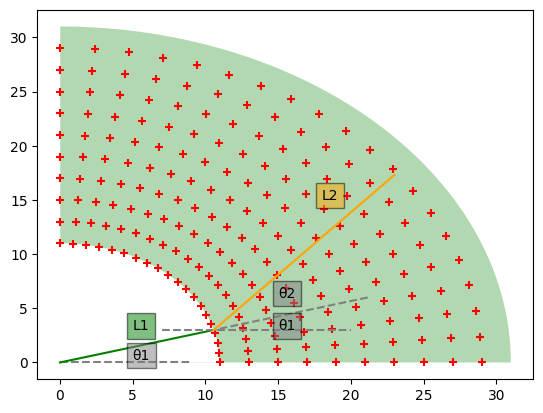

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
# Preaper training data (input)
l1, l2 = 20, 10
t = np.linspace(0, np.pi/2, 20)
l = np.arange(l1 - l2 + 1, l1 + l2 + 1, 2)
X = l.reshape(-1,1) @ np.cos(t.reshape(1,-1))
Y = l.reshape(-1,1) @ np.sin(t.reshape(1,-1))
theta = np.arange(0, np.pi/2, 0.001)
# 有效範圍填色
c1 = 11*np.cos(theta)
c2 = 11*np.sin(theta)
c3 = 31*np.cos(theta)
c4 = 31*np.sin(theta)
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.scatter(X.ravel(),Y.ravel(),marker='+',color='r')
plt.plot([0, 9], [0, 0],color="gray",linestyle='--')
plt.plot([0, 10.58], [0, 3],color="green")
plt.text(5, 3, 'L1', bbox=dict(facecolor='green', alpha=0.5))
plt.plot([21.16, 10.58], [6, 3],color="gray",linestyle='--')
plt.plot([7,20], [3, 3],color="gray",linestyle='--')
plt.plot([10.58, 23], [3, 17.3],color="orange")
plt.text(18, 15, 'L2', bbox=dict(facecolor='orange', alpha=0.5))
plt.text(5, 0.3, 'θ1', bbox=dict(facecolor='gray', alpha=0.5))
plt.text(15, 3, 'θ1', bbox=dict(facecolor='gray', alpha=0.5))
plt.text(15, 6, 'θ2', bbox=dict(facecolor='gray', alpha=0.5))
plt.show()

機器手臂範例一-以等角度間隔取樣本

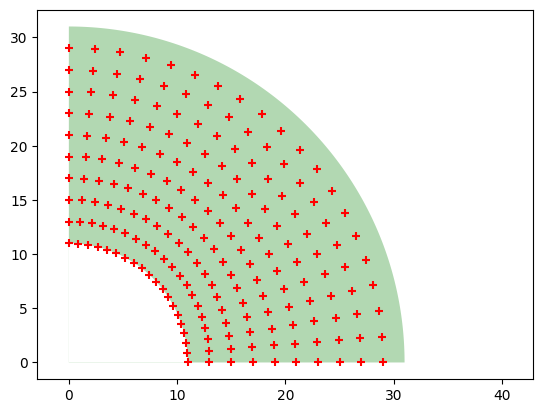

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
# Preaper training data (input)
l1, l2 = 20, 10
t = np.linspace(0, np.pi/2, 20)
l = np.arange(l1 - l2 + 1, l1 + l2 + 1, 2)
X = l.reshape(-1, 1) @ np.cos(t.reshape(1, -1))
Y = l.reshape(-1, 1) @ np.sin(t.reshape(1, -1))
# 有效範圍填色
theta = np.arange(0, np.pi/2, 0.001)
c1 = 11*np.cos(theta)
c2 = 11*np.sin(theta)
c3 = 31*np.cos(theta)
c4 = 31*np.sin(theta)
plt.fill_between(c3, c4, facecolor='g', interpolate=True, alpha=0.3)
plt.fill_between(c1, c2, facecolor='white', interpolate=True)
plt.axis('equal')
plt.xlim(0,40)
plt.scatter(X.ravel(), Y.ravel(), marker='+', color='r')
plt.show()


機器手臂範例一-以等角度間隔取樣本ANN

Root Mean square error is 0.0455


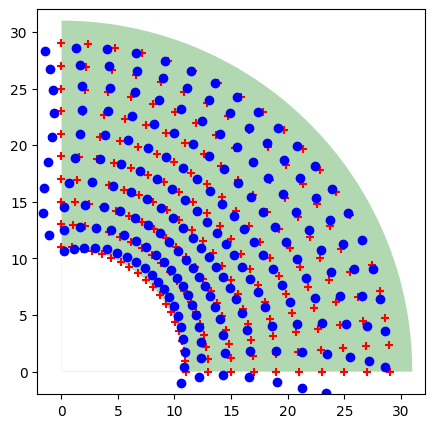

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
# Preaper training data (input)
l1, l2 = 20, 10
t = np.linspace(0, np.pi/2, 20)
l = np.arange(l1 - l2 + 1, l1 + l2 + 1, 2)
X = l.reshape(-1,1) @ np.cos(t.reshape(1,-1))
Y = l.reshape(-1,1) @ np.sin(t.reshape(1,-1))

# 有效範圍填色
c1 = 11*np.cos(theta)
c2 = 11*np.sin(theta)
c3 = 31*np.cos(theta)
c4 = 31*np.sin(theta)

# prepare training data (output)
theta2 = np.arccos((X.ravel()**2 + Y.ravel()**2 -\
        l1**2 - l2**2)/(2*l1*l2))
theta1 = np.arctan(Y.ravel()/X.ravel()) - \
        np.arctan(l2*np.sin(theta2)/(l1+l2*np.cos(theta2)))
# -------------------------------------------------------------------       
# setup for ANN training
InputX = np.c_[X.ravel(), Y.ravel()] 
OutputY = np.c_[theta1, theta2] 
hidden_layers = (10, )#一層10個
solver = 'lbfgs' # the best for robot data # solver = 'sgd'
# solver = ’adam’
mlp_reg = MLPRegressor(max_iter = 8000, solver = solver,
     hidden_layer_sizes = hidden_layers, verbose = False, 
     activation = 'logistic', # default activation = ’relu’ 
     tol=1e-6, random_state = 0)
mlp_reg.fit(InputX, OutputY) # Training ...
OutputY_hat = mlp_reg.predict(InputX) # Calculate fitted values 
theta1_hat, theta2_hat = OutputY_hat[:,0], OutputY_hat[:,1]
# convert to (x,y) positions
x_hat = l1 * np.cos(theta1_hat) + \
        l2 * np.cos(theta1_hat+theta2_hat)
y_hat = l1 * np.sin(theta1_hat) + \
        l2 * np.sin(theta1_hat+theta2_hat)
rmse = np.sqrt(mean_squared_error(OutputY, OutputY_hat))
# ------------------------------------------------------------------- 
fig = plt.figure(figsize=(5, 5))
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.scatter(X.ravel(),Y.ravel(),marker='+',color='r')
plt.scatter(x_hat,y_hat,marker='o',color='b')
plt.axis('equal')
plt.xlim(-2,32)
plt.ylim(-2,32)
print('Root Mean square error is {:.4f}'.format(rmse))


亂數生成機器人手臂樣本

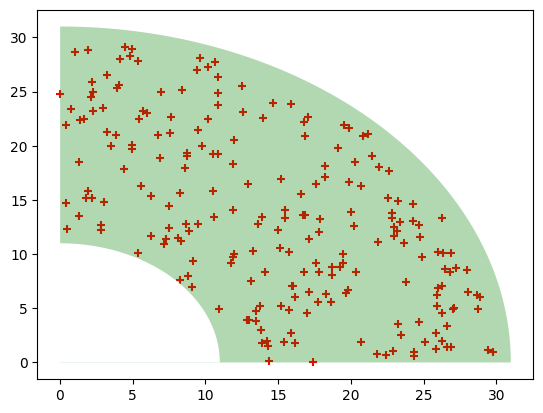

In [44]:
import neurolab as nl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.special import gammainc


def randsphere(center, radius, n_per_sphere):
    # generate random numbers in a n−dimensional sphere i.e. in 2D, it is in a circle; in 3D, it is in a ball
    r = radius
    ndim = center.size
    x = np.random.normal(size=(n_per_sphere, ndim))
    ssq = np.sum(x ** 2, axis=1)
    fr = r * gammainc(ndim / 2, ssq / 2) ** (1 / ndim)\
        / np.sqrt(ssq)
    frtiled = np.tile(fr.reshape(n_per_sphere, 1), (1, ndim))
    p = center + np.multiply(x, frtiled)
    return p


p = randsphere(np.array([0, 0]), 30, 1000)
p = p[(p[:, 0] > 0) & (p[:, 1] > 0), :]  # 取第一象限範圍 d = np.sum(p**2, axis=1)
d = np.sum(p**2, axis=1)
p = p[d >= 10**2, :]  # 扇形內
plt.scatter(p[:, 0], p[:, 1], marker='+', color='r')
# 有效範圍填色
c1 = 11*np.cos(theta)
c2 = 11*np.sin(theta)
c3 = 31*np.cos(theta)
c4 = 31*np.sin(theta)
plt.fill_between(c3, c4, facecolor='g', interpolate=True, alpha=0.3)
plt.fill_between(c1, c2, facecolor='white', interpolate=True)


亂數生成機器人手臂樣本並套用ANN

c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:559: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


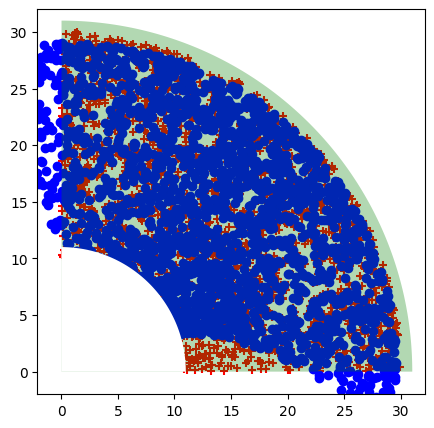

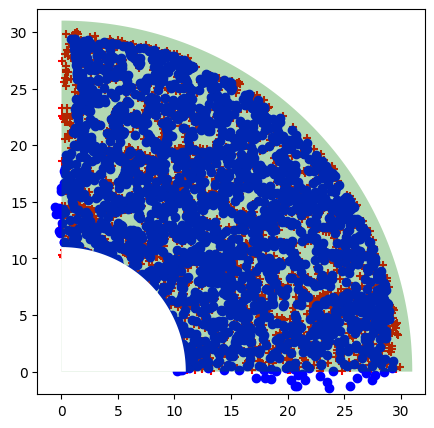

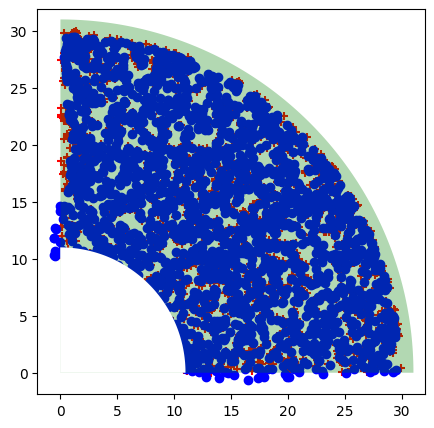

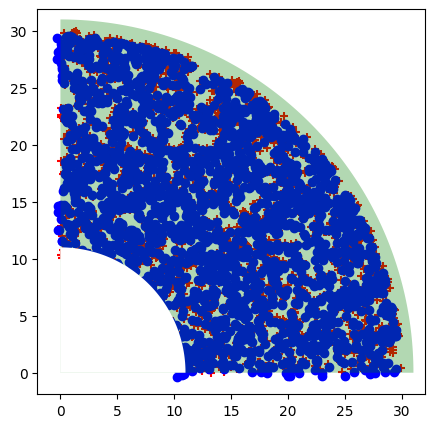

Root Mean square error 1 is 0.0681
Root Mean square error 2 is 0.0395
Root Mean square error 3 is 0.0293
Root Mean square error 4 is 0.0329


In [45]:
import neurolab as nl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.special import gammainc
def randsphere(center, radius, n_per_sphere):
#generate random numbers in a n−dimensional sphere i.e. in 2D, it is in a circle; in 3D, it is in a ball
    r = radius
    ndim = center.size
    x = np.random.normal(size=(n_per_sphere, ndim))
    ssq = np.sum(x ** 2, axis=1)
    fr = r * gammainc(ndim / 2, ssq / 2) ** (1 / ndim)\
                / np.sqrt(ssq)
    frtiled = np.tile(fr.reshape(n_per_sphere, 1), (1, ndim))
    p = center + np.multiply(x, frtiled)
    return p
p = randsphere(np.array([0, 0]), 30, 10000)
p=p[(p[:,0]>0)&(p[:,1]>0),:]# 第一象限 d = np.sum(p**2, axis=1)
d=np.sum(p**2,axis=1)
p = p[d >= 10**2, :] # 扇形內
# -------------------------------------------------------------------
# 有效範圍填色
c1 = 11*np.cos(theta)
c2 = 11*np.sin(theta)
c3 = 31*np.cos(theta)
c4 = 31*np.sin(theta)
# -------------------------------------------------------------------
# prepare training data (output)
l1, l2 = 20, 10
theta2 = np.arccos((p[:,0]**2 + p[:,1]**2 -\
        l1**2 - l2**2)/(2*l1*l2))
theta1 = np.arctan(p[:,1]/p[:,0]) - \
        np.arctan(l2*np.sin(theta2)/(l1+l2*np.cos(theta2)))
# -------------------------------------------------------------------       
# setup for ANN training
InputX = np.c_[p[:,0], p[:,1]] 
OutputY = np.c_[theta1, theta2] 
hidden_layers1 = (10, )#一層10個
hidden_layers2 = (30, )#一層30個
hidden_layers3 = (60, )#一層60個
hidden_layers4 = (90, )#一層90個
solver = 'lbfgs' # the best for robot data # solver = 'sgd'
# solver = ’adam’
mlp_reg1 = MLPRegressor(max_iter = 8000, solver = solver,
     hidden_layer_sizes = hidden_layers1, verbose = False, 
     activation = 'logistic', # default activation = ’relu’ 
     tol=1e-6, random_state = 0)
mlp_reg2 = MLPRegressor(max_iter = 8000, solver = solver,
     hidden_layer_sizes = hidden_layers2, verbose = False, 
     activation = 'logistic', # default activation = ’relu’ 
     tol=1e-6, random_state = 0)
mlp_reg3 = MLPRegressor(max_iter = 8000, solver = solver,
     hidden_layer_sizes = hidden_layers3, verbose = False, 
     activation = 'logistic', # default activation = ’relu’ 
     tol=1e-6, random_state = 0)
mlp_reg4 = MLPRegressor(max_iter = 8000, solver = solver,
     hidden_layer_sizes = hidden_layers4, verbose = False, 
     activation = 'logistic', # default activation = ’relu’ 
     tol=1e-6, random_state = 0)

mlp_reg1.fit(InputX, OutputY) # Training ...
mlp_reg2.fit(InputX, OutputY) # Training ...
mlp_reg3.fit(InputX, OutputY) # Training ...
mlp_reg4.fit(InputX, OutputY) # Training ...
OutputY_hat1 = mlp_reg1.predict(InputX) # Calculate fitted values 
OutputY_hat2 = mlp_reg2.predict(InputX) # Calculate fitted values 
OutputY_hat3 = mlp_reg3.predict(InputX) # Calculate fitted values 
OutputY_hat4 = mlp_reg4.predict(InputX) # Calculate fitted values 

theta1_hat1, theta2_hat1 = OutputY_hat1[:,0], OutputY_hat1[:,1]
theta1_hat2, theta2_hat2 = OutputY_hat2[:,0], OutputY_hat2[:,1]
theta1_hat3, theta2_hat3 = OutputY_hat3[:,0], OutputY_hat3[:,1]
theta1_hat4, theta2_hat4 = OutputY_hat4[:,0], OutputY_hat4[:,1]

# convert to (x,y) positions
x_hat1 = l1 * np.cos(theta1_hat1) + \
        l2 * np.cos(theta1_hat1+theta2_hat1)
y_hat1 = l1 * np.sin(theta1_hat1) + \
        l2 * np.sin(theta1_hat1+theta2_hat1)

x_hat2 = l1 * np.cos(theta1_hat2) + \
        l2 * np.cos(theta1_hat2+theta2_hat2)
y_hat2 = l1 * np.sin(theta1_hat2) + \
        l2 * np.sin(theta1_hat2+theta2_hat2)

x_hat3 = l1 * np.cos(theta1_hat3) + \
        l2 * np.cos(theta1_hat3+theta2_hat3)
y_hat3 = l1 * np.sin(theta1_hat3) + \
        l2 * np.sin(theta1_hat3+theta2_hat3)

x_hat4 = l1 * np.cos(theta1_hat4) + \
        l2 * np.cos(theta1_hat4+theta2_hat4)
y_hat4 = l1 * np.sin(theta1_hat4) + \
        l2 * np.sin(theta1_hat4+theta2_hat4)

rmse1 = np.sqrt(mean_squared_error(OutputY, OutputY_hat1))
rmse2 = np.sqrt(mean_squared_error(OutputY, OutputY_hat2))
rmse3 = np.sqrt(mean_squared_error(OutputY, OutputY_hat3))
rmse4 = np.sqrt(mean_squared_error(OutputY, OutputY_hat4))
fig = plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.xlim(-2,32)
plt.ylim(-2,32)
plt.scatter(p[:,0],p[:,1],marker='+',color='r')
plt.scatter(x_hat1,y_hat1,marker='o',color='b')
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.show()
fig = plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.xlim(-2,32)
plt.ylim(-2,32)
plt.scatter(p[:,0],p[:,1],marker='+',color='r')
plt.scatter(x_hat2,y_hat2,marker='o',color='b')
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.show()
fig = plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.xlim(-2,32)
plt.ylim(-2,32)
plt.scatter(p[:,0],p[:,1],marker='+',color='r')
plt.scatter(x_hat3,y_hat3,marker='o',color='b')
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.show()
fig = plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.xlim(-2,32)
plt.ylim(-2,32)
plt.scatter(p[:,0],p[:,1],marker='+',color='r')
plt.scatter(x_hat4,y_hat4,marker='o',color='b')
plt.fill_between(c3,c4,facecolor='g',interpolate=True,alpha=0.3)
plt.fill_between(c1,c2,facecolor='white',interpolate=True)
plt.show()

print('Root Mean square error 1 is {:.4f}'.format(rmse1))
print('Root Mean square error 2 is {:.4f}'.format(rmse2))
print('Root Mean square error 3 is {:.4f}'.format(rmse3))
print('Root Mean square error 4 is {:.4f}'.format(rmse4))



In [1]:
from scipy.io import loadmat
data_dir = 'Data/'
D = loadmat(data_dir + 'Digits_train.mat') # D.keys()
X = D['X'] # images
y = D['y'] # labels: single output in 0~9


匯入圖檔

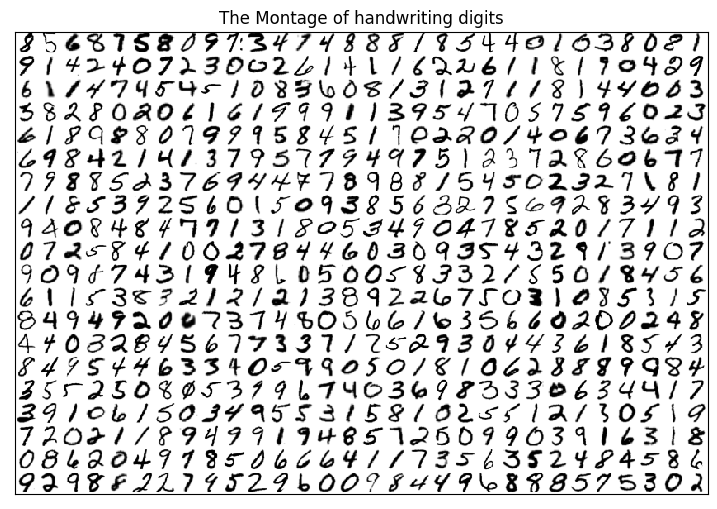

In [3]:
from scipy.io import loadmat
data_dir = 'Data/'
D = loadmat(data_dir + 'Digits_train.mat')  # D.keys()
X = D['X']  # images
y = D['y']  # labels: single output in 0~9
plt.figure(figsize=(9, 6))
n, m = 20, 30  # Anxmmontage(totalmnimages)
# prepare and diaplay a montage of digit images n,m=20,30 #Anxmmontage(totalmnimages)
# image size sz x sz M = np.zeros((m*sz, n*sz)) # montage image
sz = np.sqrt(X.shape[1]).astype('int')
M = np.zeros((m*sz, n*sz))  # montage image
A = X[:m*n, :]  # show the first nm images
# Arrange images to form a montage
for i in range(m):
    for j in range(n):
        M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
            A[i*n+j, :].reshape(sz, sz)
plt.imshow(M.T, cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.title('The Montage of handwriting digits')
plt.show()


圖檔應用ANN模型

Iteration 1, loss = 2.32671308
Iteration 2, loss = 2.24621551
Iteration 3, loss = 2.17970992
Iteration 4, loss = 2.11978243
Iteration 5, loss = 2.06254833
Iteration 6, loss = 2.00765428
Iteration 7, loss = 1.95487987
Iteration 8, loss = 1.90489133
Iteration 9, loss = 1.85804464
Iteration 10, loss = 1.81290768
Iteration 11, loss = 1.76979983
Iteration 12, loss = 1.72843429
Iteration 13, loss = 1.68794124
Iteration 14, loss = 1.65002039
Iteration 15, loss = 1.61243414
Iteration 16, loss = 1.57607573
Iteration 17, loss = 1.54067408
Iteration 18, loss = 1.50625913
Iteration 19, loss = 1.47299267
Iteration 20, loss = 1.44004670
Iteration 21, loss = 1.40820554
Iteration 22, loss = 1.37684967
Iteration 23, loss = 1.34634037
Iteration 24, loss = 1.31635766
Iteration 25, loss = 1.28732651
Iteration 26, loss = 1.25869595
Iteration 27, loss = 1.23094653
Iteration 28, loss = 1.20396480
Iteration 29, loss = 1.17731868
Iteration 30, loss = 1.15168717
Iteration 31, loss = 1.12680991
Iteration 32, los

c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


<Figure size 900x600 with 0 Axes>

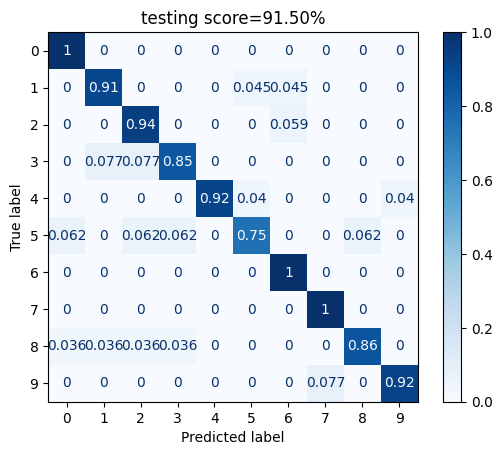

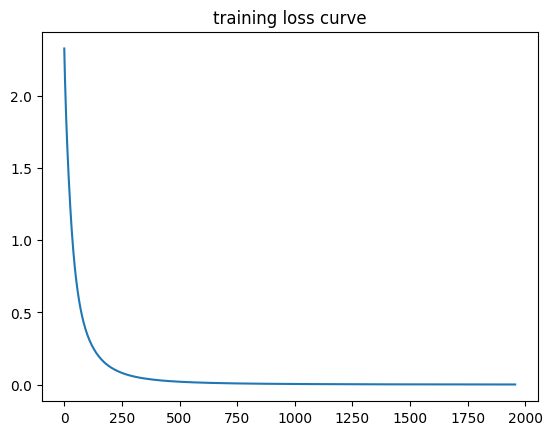

accurary by score for tested data:91.50%


In [67]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import plot_confusion_matrix
data_dir = 'Data/'
D = loadmat(data_dir + 'Digits_train.mat')  # D.keys()
X = D['X']  # images
y = D['y']  # labels: single output in 0~9
plt.figure(figsize=(9, 6))

# prepare data
X_train, X_test, y_train, y_test = \
    train_test_split(X/255, y.ravel(), test_size=0.2)
# setup and run
hidden_layers = (30,)  # one hidden layer
# solver = ’sgd’ # not efficient, need more tuning # solver = ’lbfgs’ # not suitable here
solver = 'adam'  # default solver
clf = MLPClassifier(max_iter=10000, solver=solver,
                    hidden_layer_sizes=hidden_layers, verbose=True, activation='logistic', tol=1e-6, random_state=0)  # default activation = ’relu’
clf.fit(X_train, y_train)
y_test_hat = clf.predict(X_test)
score = clf.score(X_test, y_test)
plot_confusion_matrix(clf, X_test, y_test,
                      cmap=plt.cm.Blues, normalize='true')

plt.title("testing score={:.2f}%".format(100*clf.score(X_test, y_test)))
plt.show()
plt.plot(clf.loss_curve_)
plt.title("training loss curve")
plt.show()
print('accurary by score for tested data:{:.2f}%'.format(
    100*clf.score(X_test, y_test)))
